In [1]:
import pandas as pd

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf   

In [3]:
# spy = yf.download(
#    tickers = "SPY",
#    start = "2005-01-01",
#    end = "2025-01-01",
#    multi_level_index = False
# )

In [4]:
spy = pd.read_csv(
    "data/spy.csv",
    index_col="Date",
    parse_dates=True
    )

In [5]:
spy.head()

,Close,High,Low,Open,Volume
Date,,,,,
2005-01-03,80.973511,81.956231,80.704271,81.821609,55748000
2005-01-04,79.984077,81.135072,79.721570,81.081223,69167600
2005-01-05,79.432137,80.266775,79.425404,79.923494,65667300
2005-01-06,79.835991,80.199464,79.600408,79.721566,47814700
2005-01-07,79.721588,80.253335,79.512925,80.078329,55847700


In [6]:
spy.tail()

,Close,High,Low,Open,Volume
Date,,,,,
2024-12-24,589.714722,589.753989,583.997032,584.575691,33160100
2024-12-26,589.753967,590.871957,586.556768,587.949392,41219100
2024-12-27,583.545898,586.262548,579.377784,586.027122,64969300
2024-12-30,576.886719,580.338918,573.150129,576.563120,56578800
2024-12-31,574.788025,579.260165,573.159975,578.544189,57052700


In [7]:
#spy.to_csv("data/spy.csv")

Text(0.5, 1.0, 'Graphique du prix')

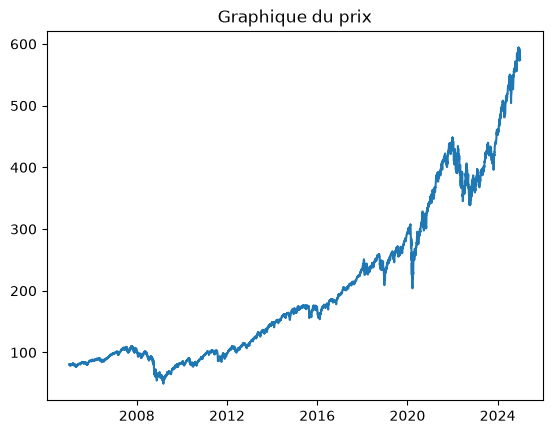

In [8]:
plt.plot(spy.Close)
plt.title("Graphique du prix")

In [9]:
spy["mm50"] = spy.Close.rolling(50).mean()
spy["mm200"] = spy.Close.rolling(200).mean()
spy.tail()

,Close,High,Low,Open,Volume,mm50,mm200
Date,,,,,,,
2024-12-24,589.714722,589.753989,583.997032,584.575691,33160100,578.749701,538.074202
2024-12-26,589.753967,590.871957,586.556768,587.949392,41219100,579.210740,538.520950
2024-12-27,583.545898,586.262548,579.377784,586.027122,64969300,579.498353,538.940580
2024-12-30,576.886719,580.338918,573.150129,576.563120,56578800,579.651808,539.331852
2024-12-31,574.788025,579.260165,573.159975,578.544189,57052700,579.719497,539.729750


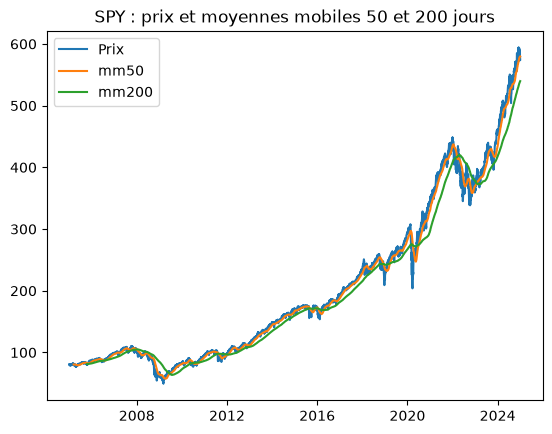

In [10]:
plt.plot(spy.Close, label="Prix")
plt.plot(spy.mm50, label="mm50")
plt.plot(spy.mm200, label="mm200")

plt.legend()
plt.title("SPY : prix et moyennes mobiles 50 et 200 jours")
plt.show()


In [11]:
spy["signal"] = (spy["mm50"] > spy["mm200"]).astype(int)
spy["signal"].value_counts()

signal
1    3777
0    1256
Name: count, dtype: int64

In [12]:
spy["position"] = spy["signal"].shift(1)
spy.loc["2020-03-30":"2020-04-01"]

,Close,High,Low,Open,Volume,mm50,mm200,signal,position
Date,,,,,,,,,
2020-03-30,239.307190,240.020583,231.880577,233.865275,171369500,274.221476,273.699190,1,1.0
2020-03-31,235.740265,240.843766,234.340915,238.310312,194881100,272.899695,273.581581,0,1.0
2020-04-01,225.130798,235.657947,223.072930,226.804533,189554600,271.377543,273.410431,0,0.0


In [13]:
spy["rendement"] = spy["Close"].pct_change()
spy.loc["2020-03-30":"2020-04-01"]

,Close,High,Low,Open,Volume,mm50,mm200,signal,position,rendement
Date,,,,,,,,,,
2020-03-30,239.307190,240.020583,231.880577,233.865275,171369500,274.221476,273.699190,1,1.0,0.032476
2020-03-31,235.740265,240.843766,234.340915,238.310312,194881100,272.899695,273.581581,0,1.0,-0.014905
2020-04-01,225.130798,235.657947,223.072930,226.804533,189554600,271.377543,273.410431,0,0.0,-0.045005


In [14]:
spy["rendement_strat"] = spy["rendement"]*spy["position"]
spy.loc["2020-03-30":"2020-04-01"]

,Close,High,Low,Open,Volume,mm50,mm200,signal,position,rendement,rendement_strat
Date,,,,,,,,,,,
2020-03-30,239.307190,240.020583,231.880577,233.865275,171369500,274.221476,273.699190,1,1.0,0.032476,0.032476
2020-03-31,235.740265,240.843766,234.340915,238.310312,194881100,272.899695,273.581581,0,1.0,-0.014905,-0.014905
2020-04-01,225.130798,235.657947,223.072930,226.804533,189554600,271.377543,273.410431,0,0.0,-0.045005,-0.000000


In [15]:
bt = spy.loc["2005-10-18":]
bt.loc["2005-03-30":"2020-04-01"]

,Close,High,Low,Open,Volume,mm50,mm200,signal,position,rendement,rendement_strat
Date,,,,,,,,,,,
2005-10-18,80.277359,81.054104,80.263734,81.040480,74996900,82.763745,81.202934,1,1.0,-0.010830,-0.010830
2005-10-19,81.612808,81.626438,79.800404,80.059318,116563800,82.721679,81.211078,1,1.0,0.016635,0.016635
2005-10-20,80.175140,81.633241,79.923042,81.415208,131966700,82.651673,81.214793,1,1.0,-0.017616,-0.017616
2005-10-21,80.488579,80.931461,80.066141,80.597598,96579500,82.581287,81.218056,1,1.0,0.003909,0.003909
2005-10-24,81.735443,81.824017,80.679345,80.699785,71308400,82.546151,81.228125,1,1.0,0.015491,0.015491
...,...,...,...,...,...,...,...,...,...,...,...
2020-03-26,238.895676,240.359026,227.783178,228.213045,257632800,276.785800,273.933911,1,1.0,0.058390,0.058390
2020-03-27,231.779984,238.538937,229.612367,231.642798,224341200,275.453188,273.800399,1,1.0,-0.029786,-0.029786
2020-03-30,239.307190,240.020583,231.880577,233.865275,171369500,274.221476,273.699190,1,1.0,0.032476,0.032476


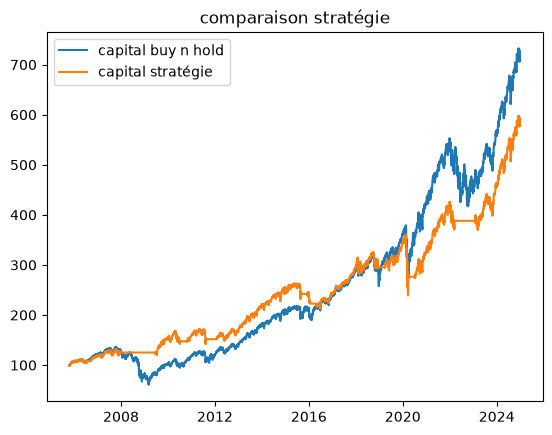

In [16]:
bt["capital_bh"] = (1 + bt["rendement"]).cumprod()*100
bt["capital_strat"] = (1 + bt["rendement_strat"]).cumprod()*100
bt.loc["2024-12-31":]
plt.plot(bt.capital_bh, label="capital buy n hold")
plt.plot(bt.capital_strat, label="capital stratégie")
plt.legend()
plt.title("comparaison stratégie")
plt.show()